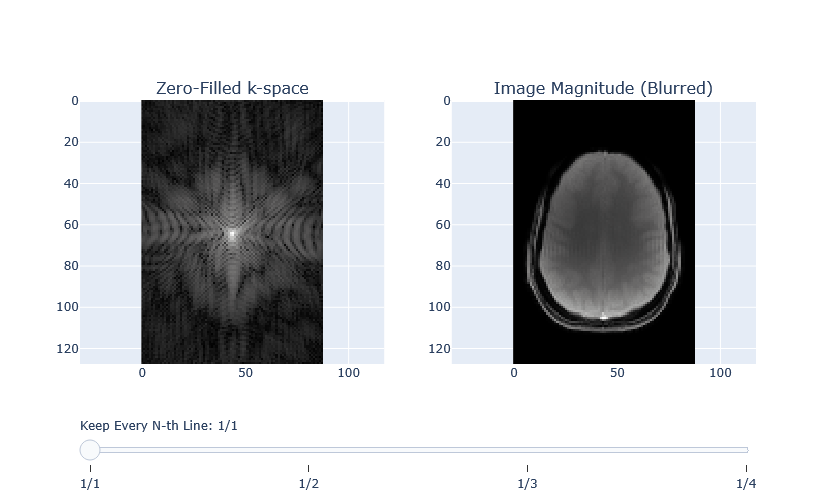

In [4]:
#| label: fig6

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Load data
k_space_orig = np.load('kspace_combined.npy')
rows, cols = k_space_orig.shape

# 2. Subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Zero-Filled k-space", "Image Magnitude (Blurred)"))
frames, steps = [], []
step_factors = [1, 2, 3, 4]

for i, sf in enumerate(step_factors):
    # Create empty matrix (zeros) and fill only the acquired lines
    k_space_zf = np.zeros_like(k_space_orig, dtype=complex)
    k_space_zf[::sf, :] = k_space_orig[::sf, :]
    
    # Reconstruct
    img_zf = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k_space_zf)))
    img_mag = np.abs(img_zf)
    k_log = np.log(np.abs(k_space_zf) + 1e-5)
    
    if i == 0:
        fig.add_trace(go.Heatmap(z=k_log, colorscale='gray', showscale=False), row=1, col=1)
        fig.add_trace(go.Heatmap(z=img_mag, colorscale='gray', showscale=False), row=1, col=2)
        
    frames.append(go.Frame(data=[go.Heatmap(z=k_log), go.Heatmap(z=img_mag)], name=str(sf)))
    steps.append(dict(
        method="animate", 
        args=[[str(sf)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}], 
        label=f"1/{sf}"
    ))

# 3. Layout
fig.frames = frames
fig.update_layout(
    sliders=[dict(active=0, currentvalue={"prefix": "Keep Every N-th Line: "}, pad={"t": 50}, steps=steps)], 
    height=500,
    yaxis=dict(scaleanchor="x", autorange="reversed"),
    yaxis2=dict(scaleanchor="x2", autorange="reversed")
)
fig